In [1]:
!pip install ultralytics timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.5 MB/s eta 0:00:00


In [2]:
import os
import cv2
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix

import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [4]:
DATASET_PATH = "/kaggle/input/datasets/avins2005/pest-data/Pest Data"

train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")
test_dir  = os.path.join(DATASET_PATH, "test")

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [6]:
class LeafDataset(Dataset):
    
    def __init__(self, root_dir, transform=None):
        
        self.image_paths = []
        self.labels = []
        self.transform = transform
        
        classes = ["Healthy", "Pest Attack"]
        
        for label, class_name in enumerate(classes):
            
            image_folder = os.path.join(root_dir, class_name, "images")
            
            valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

            for img_name in os.listdir(image_folder):
    
                if img_name.lower().endswith(valid_extensions):
        
                    img_path = os.path.join(image_folder, img_name)

                    self.image_paths.append(img_path)
                    self.labels.append(label)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        
        img_path = self.image_paths[idx]
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        label = self.labels[idx]
        
        return image, label

In [7]:
train_dataset = LeafDataset(train_dir, transform)
valid_dataset = LeafDataset(valid_dir, transform)
test_dataset  = LeafDataset(test_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Train: 5700
Valid: 800
Test : 232


In [8]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=2
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [10]:
def train_model(model, train_loader, valid_loader, epochs):
    
    best_acc = 0
    
    for epoch in range(epochs):
        
        model.train()
        
        train_loss = 0
        correct = 0
        total = 0
        
        for images, labels in tqdm(train_loader):
            
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            loss.backward()
            
            optimizer.step()
            
            train_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_acc = 100 * correct / total
        
        # Validation
        
        model.eval()
        
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            
            for images, labels in valid_loader:
                
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                
                _, predicted = torch.max(outputs, 1)
                
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = 100 * val_correct / val_total
        
        print(f"\nEpoch {epoch+1}")
        print(f"Train Accuracy: {train_acc:.2f}%")
        print(f"Validation Accuracy: {val_acc:.2f}%")
        
        # Save best model
        
        if val_acc > best_acc:
            
            best_acc = val_acc
            
            torch.save(model.state_dict(), "best_efficientnetb0.pth")
            
            print("Best Model Saved!")

In [11]:
train_model(
    model,
    train_loader,
    valid_loader, 
    epochs=10
)

100%|██████████| 179/179 [01:45<00:00,  1.70it/s]



Epoch 1
Train Accuracy: 92.61%
Validation Accuracy: 87.38%
Best Model Saved!


100%|██████████| 179/179 [01:05<00:00,  2.75it/s]



Epoch 2
Train Accuracy: 98.81%
Validation Accuracy: 86.88%


100%|██████████| 179/179 [01:12<00:00,  2.47it/s]


...


Epoch 8
Train Accuracy: 99.74%
Validation Accuracy: 86.50%


100%|██████████| 179/179 [01:22<00:00,  2.16it/s]



Epoch 9
Train Accuracy: 99.68%
Validation Accuracy: 89.25%


100%|██████████| 179/179 [01:07<00:00,  2.67it/s]



Epoch 10
Train Accuracy: 99.86%
Validation Accuracy: 88.12%


In [12]:
model.load_state_dict(torch.load("best_efficientnetb0.pth"))

model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"\nTest Accuracy: {accuracy:.2f}%")


Test Accuracy: 93.10%


In [13]:
classes = ["Healthy", "Pest Attack"]

print(classification_report(
    all_labels,
    all_preds,
    target_names=classes
))

              precision    recall  f1-score   support

     Healthy       0.91      0.91      0.91        88
 Pest Attack       0.94      0.94      0.94       144

    accuracy                           0.93       232
   macro avg       0.93      0.93      0.93       232
weighted avg       0.93      0.93      0.93       232



In [14]:
def predict_image(image_path):
    
    image = Image.open(image_path).convert("RGB")
    
    image_resized = transform(image).unsqueeze(0).to(device)
    
    model.eval()
    
    with torch.no_grad():
        
        outputs = model(image_resized)
        
        probabilities = torch.softmax(outputs, dim=1)
        
        confidence, prediction = torch.max(probabilities, 1)
    
    classes = ["Healthy", "Pest Attack"]
    
    predicted_class = classes[prediction.item()]
    
    confidence_score = confidence.item() * 100
    
    # Show image
    
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(6,6))
    
    plt.imshow(img)
    
    plt.title(f"{predicted_class} ({confidence_score:.2f}%)")
    
    plt.axis("off")
    
    plt.show()

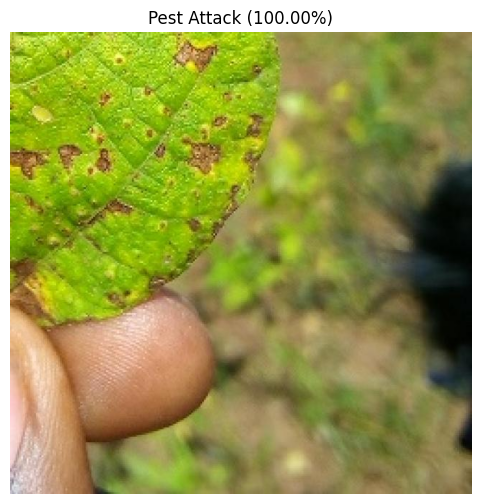

In [15]:
predict_image("/kaggle/input/datasets/avins2005/pest-data/Pest Data/test/Pest Attack/images/pest attack_train-67_jpg.rf.7515fb08d5339fbc20dc87fd4937bfe5.jpg")